# Neural tissue segmentation with simulated training data

## 1. Preparing the data to segment

Start by downloading the data

In [2]:
import os
import deeptrack as dt

if not os.path.exists("tissue_images_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/tissue_images_dataset")

raw_path = os.path.join("tissue_images_dataset", "stack1", "raw")
seg_path = os.path.join("tissue_images_dataset", "stack1", "labels")

raw_paths = dt.sources.ImageFolder(root=raw_path)
seg_paths = dt.sources.ImageFolder(root=seg_path)
path = dt.sources.Source(raw=raw_paths, label=seg_paths)
srcs = path.product(flip_ud=[True, False], flip_lr=[True, False])

sources = dt.sources.Join(srcs)

print(f"Raw images: {len(raw_paths)}")
print(f"Segmentation labels: {len(seg_paths)}")

Raw images: 20
Segmentation labels: 20


### 1.1 Create data pipeline
To get images and segmentation masks

In [3]:
import numpy as np

def select_labels(class_labels):
    """Create a function to filter and remap labels in a segmentation map."""
    def inner(segmentation):
        seg = segmentation.copy()
        mask = seg * np.isin(seg, class_labels).astype(np.uint8)
        new_seg = (np.select([mask == c for c in class_labels],
                             np.arange(len(class_labels)) + 1)
                   .astype(np.uint8).squeeze())
        one_hot_encoded_seg = np.eye(len(class_labels) + 1)[new_seg]
        return one_hot_encoded_seg        
    return inner

In [4]:
import torch

im_pip_exp = dt.LoadImage(sources.raw.path) >> dt.NormalizeMinMax()
seg_pip_exp = (dt.LoadImage(sources.label.path)
           >> dt.Lambda(select_labels, class_labels=[255, 191]))
pip_exp = ((im_pip_exp & seg_pip_exp) >> dt.FlipLR(sources.flip_lr)
       >> dt.FlipUD(sources.flip_ud) >> dt.MoveAxis(2, 0)
       >> dt.pytorch.ToTensor(dtype=torch.float))

In [5]:
exp_dataset = dt.pytorch.Dataset(pip_exp, srcs)

### 1.2 Visualize an experimental sample

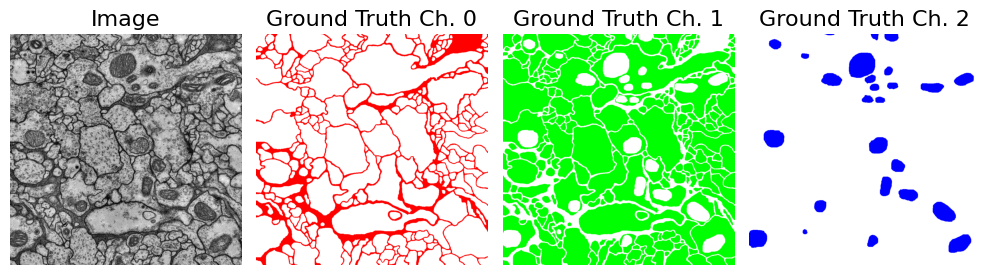

In [6]:
import matplotlib.pyplot as plt

image, segmentation = exp_dataset[0]

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

for i in range(segmentation.shape[0]):
    segmentation_color = torch.ones_like(segmentation)
    for j in range(segmentation.shape[0]):
        if j != i: segmentation_color[j, ...] = 1 - segmentation[i, ...]
    axs[i + 1].imshow(segmentation_color.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

To decrease the training speed: simulate images 1/4 of the size of the experimental images

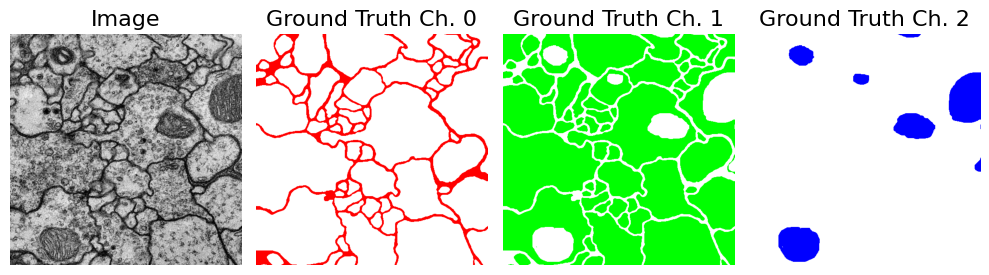

In [7]:
image, segmentation = exp_dataset[0]

size = image.shape[1]//2

image = image[:, :size, :size]
segmentation = segmentation[:, :size, :size]

fig, axs = plt.subplots(1, 4, figsize=(10, 5))

axs[0].imshow(image.permute(1, 2, 0), cmap="gray")
axs[0].set_title("Image", fontsize=16)
axs[0].set_axis_off()

for i in range(segmentation.shape[0]):
    segmentation_color = torch.ones_like(segmentation)
    for j in range(segmentation.shape[0]):
        if j != i: segmentation_color[j, ...] = 1 - segmentation[i, ...]
    axs[i + 1].imshow(segmentation_color.permute(1, 2, 0))
    axs[i + 1].set_title(f"Ground Truth Ch. {i}", fontsize=16)
    axs[i + 1].set_axis_off()

plt.tight_layout()
plt.show()

## 2. Simulate the data

### 2.1 Membrane

In [8]:
import cv2
from scipy.spatial import Voronoi


class Membrane(dt.Feature):
    def __init__(
        self,
        image_size,
        num_points=40,
        num_clusters=4,
        num_random_points=15,
        thickness=4,
        fill_probability=0.2,
        mitochondria_sites=None,
        mitochondria_size=None,
        **kwargs
    ):
        super().__init__(  # all the variables for the "get" seem to have to be here. Otherwise, they don't work with lambda functions
            image_size=image_size,
            num_points=num_points,
            num_clusters=num_clusters,
            num_random_points=num_random_points,
            thickness=thickness,
            mitochondria_sites=mitochondria_sites,
            mitochondria_size=mitochondria_size,
            **kwargs,
        )

        self.fill_probability = fill_probability

    def generate_clustered_points(
        self, image_size, num_clusters, num_points, num_random_points
    ):

        # create cluster locations and standard deviations
        cluster_centers = np.random.uniform(
            -0.075 * image_size, 1.075 * image_size, size=(num_clusters, 2)
        )
        cluster_stds = np.random.uniform(
            0.05 * image_size, 0.1 * image_size, size=(num_clusters, 2)
        )

        # randomly put points into clusters
        cluster_ids = np.random.choice(num_clusters, size=num_points)

        # these points get positions from the distribution they belong to
        clustered_points = np.random.normal(
            loc=cluster_centers[cluster_ids], scale=cluster_stds[cluster_ids]
        )

        # add random points
        if num_random_points > 0:
            random_points = np.random.uniform(
                -0.3 * image_size,
                1.3 * image_size,
                size=(num_random_points, 2),
            )
            points = np.vstack([clustered_points, random_points])

        else:
            points = clustered_points

        return points

    def draw_line(self, start, end, mask, thickness):
        cv2.polylines(
            mask,
            [np.array([start, end], dtype=np.int32)],
            isClosed=False,
            color=1,
            thickness=thickness,
        )

    def get(
        self,
        image,
        image_size,
        num_clusters,
        num_points,
        num_random_points,
        thickness,
        **kwargs
    ):
        points = self.generate_clustered_points(
            image_size=image_size,
            num_clusters=num_clusters,
            num_points=num_points,
            num_random_points=num_random_points,
        )

        vor = Voronoi(points)

        mask = np.zeros((image_size, image_size, 1), dtype=float)

        for ridge in vor.ridge_vertices:
            if -1 not in ridge:
                start = vor.vertices[ridge[0]]
                end = vor.vertices[ridge[1]]
                self.draw_line(start, end, mask, thickness)

        areas = []
        centroids = []

        # Fill some small areas & find big areas for placing mitochondria
        for region_idx in vor.point_region:
            region = vor.regions[region_idx]
            if not -1 in region and len(region) > 0:
                polygon = np.array(
                    [vor.vertices[i] for i in region], dtype=np.int32
                )

                # Compute polygon area
                area = cv2.contourArea(polygon)
                relative_area = area / (image_size * image_size)

                # Map area to a probability: small → larger fill probability,
                # large → small fill probability
                size_factor = np.exp(-relative_area * 40)

                # Final probability
                p = self.fill_probability * size_factor

                # Fill
                if np.random.rand() < p:
                    cv2.fillPoly(mask, [polygon], 1)

                # Find centroid of the polygon
                M = cv2.moments(polygon)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroid = (cx, cy)

                    # only store the position if the centroid is inside the
                    # image boundaries
                    if (
                        (cx > 0)
                        & (cx < image_size)
                        & (cy > 0)
                        & (cy < image_size)
                    ):

                        # only store if the centroid is not in a filled area
                        if mask[cy, cx] == 0:

                            # store centroid and area
                            areas.append(area)
                            centroids.append(centroid)

        # Keep top 10 largest
        top_idx = np.argsort(areas)[-10:]
        self.mitochondria_sites = np.array([centroids[i] for i in top_idx])
        self.mitochondria_size = np.array([areas[i] for i in top_idx])

        return mask + image

In [9]:
image_size = 512

# pad image to get rid of edge effects of the membrane simulation
pad = 10
image_size_padded = image_size + 2 * pad

membrane = Membrane(
    image_size=image_size_padded,
    num_points=lambda: np.random.randint(35, 45),
    num_clusters=lambda: np.random.randint(4, 6),
    num_random_points=15,
)

In [10]:
mem_pip = (
    dt.Value(np.zeros((image_size_padded, image_size_padded, 1), dtype=float))
    >> membrane
    >> dt.ElasticTransformation(alpha=1000, sigma=14)
    >> dt.ElasticTransformation(alpha=10, sigma=5)
    >> dt.AverageBlur(ksize=7)
    >> dt.ElasticTransformation(alpha=10, sigma=2.8)
    >> dt.GreaterThan(0.25)
)

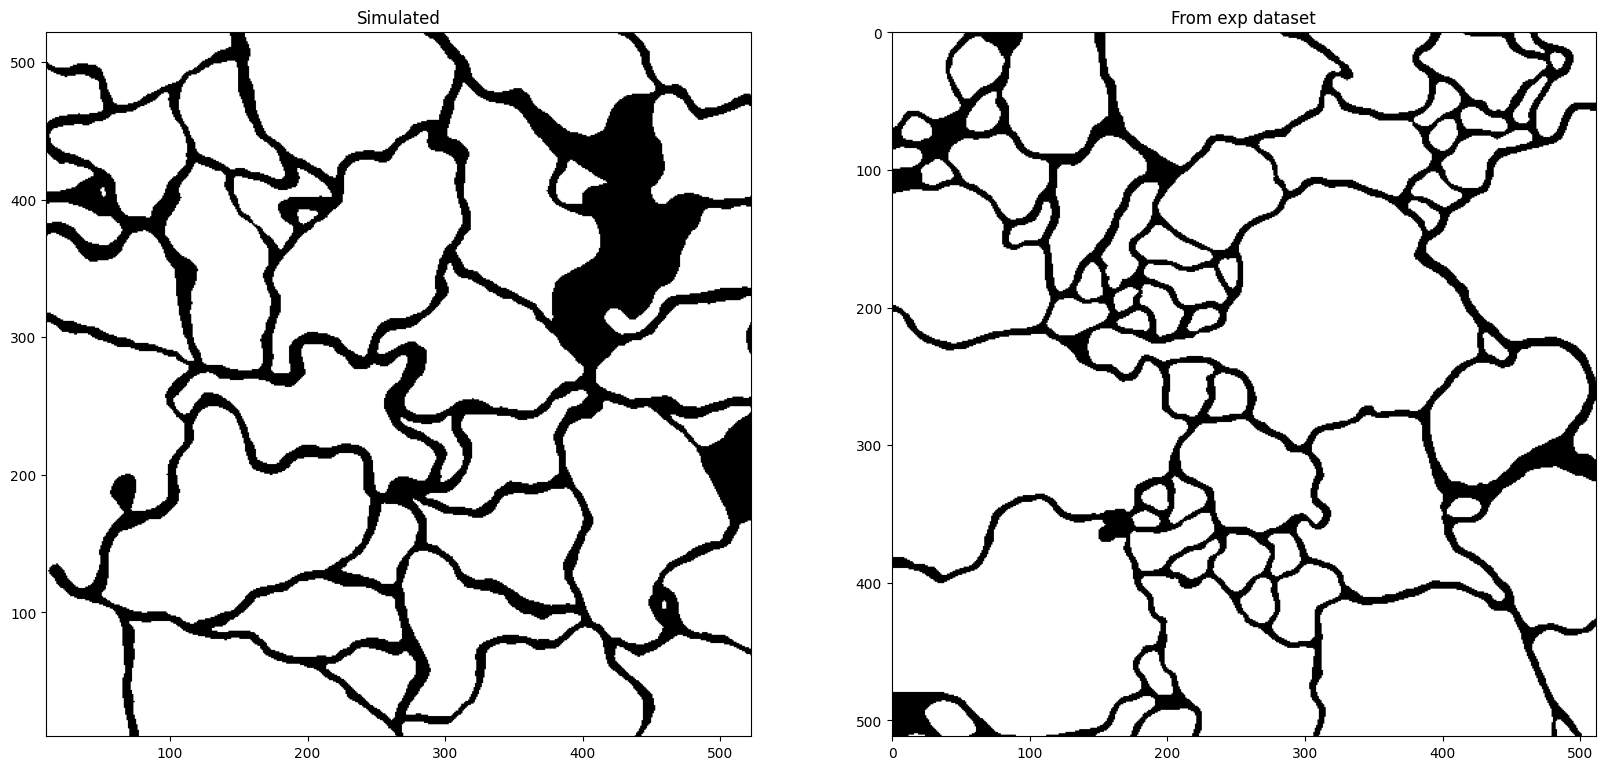

In [11]:
mem_pip.update()
im = mem_pip.resolve()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(im, cmap='gray_r')
ax[0].set_xlim(pad, image_size_padded-pad)
ax[0].set_ylim(pad, image_size_padded-pad)
ax[0].set_title('Simulated')
ax[1].imshow(1 - segmentation[0, ...], cmap='gray')
ax[1].set_title('From exp dataset');

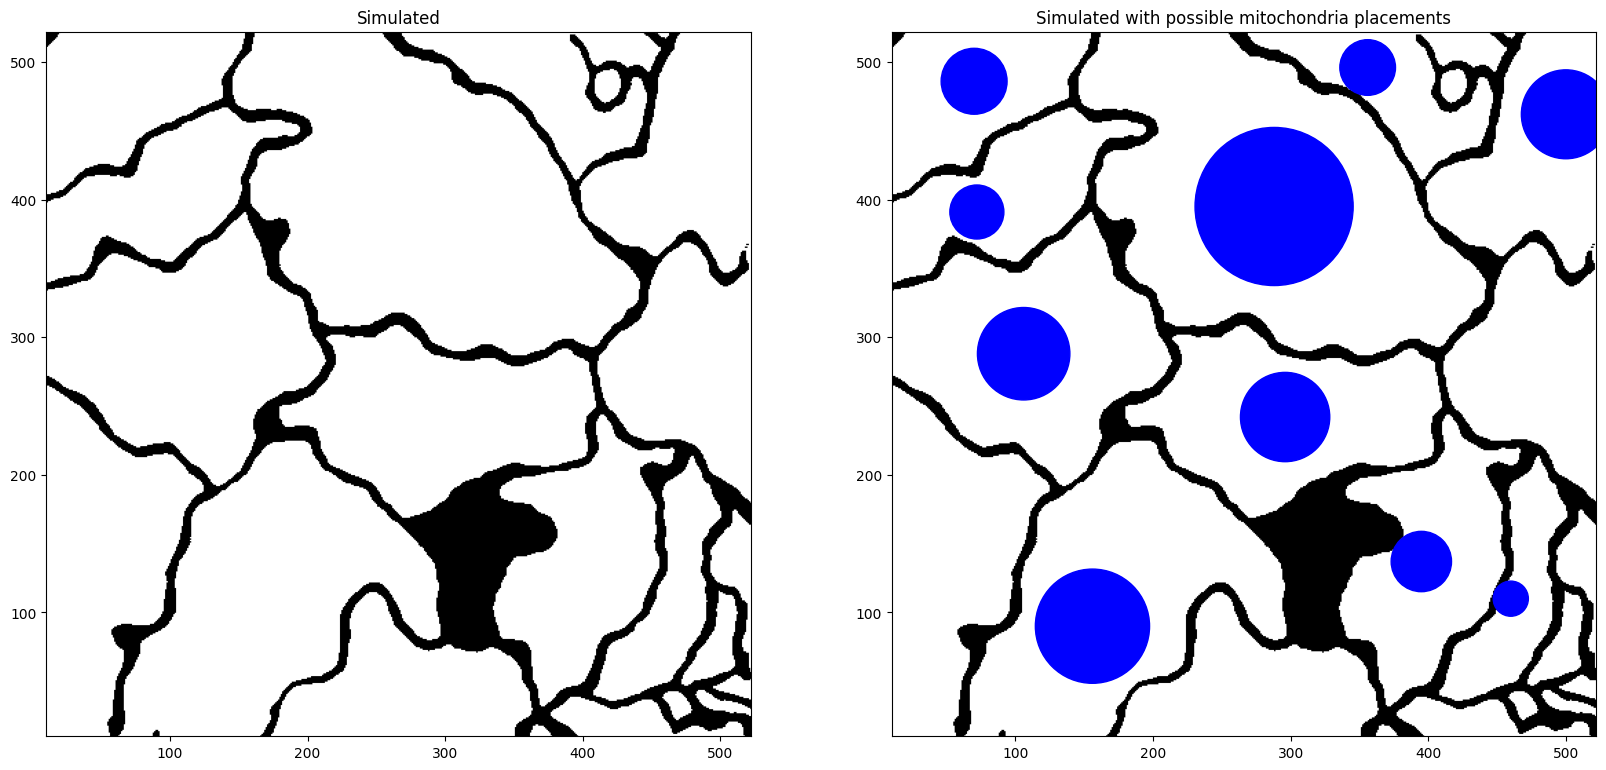

In [12]:
mem_pip.update()
im = mem_pip.resolve()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(im, cmap='gray_r')
ax[0].set_xlim(pad, image_size_padded-pad)
ax[0].set_ylim(pad, image_size_padded-pad)
ax[0].set_title('Simulated')
ax[1].imshow(im, cmap='gray_r')
ax[1].set_xlim(pad, image_size_padded-pad)
ax[1].set_ylim(pad, image_size_padded-pad)
ax[1].set_title('Simulated with possible mitochondria placements')

s = membrane.mitochondria_sites
r = membrane.mitochondria_size
ax[1].scatter(s[:, 0], s[:, 1], c='b', s=5e-5*r**1.8);